# Time Series Analysis

You can use the following link to get the dataset: https://www.kaggle.com/datasets/chirag19/air-passengers

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller,acf,pacf
from statsmodels.tsa.arima_model import ARIMA

In [2]:
df = pd.read_csv('AirPassengers.csv')
df.columns = ['Month', 'Passengers']
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


## EDA

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Month       144 non-null    object
 1   Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [4]:
df.isnull().sum()

Month         0
Passengers    0
dtype: int64

In [5]:
df.describe()

,Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


## Time Feacture Extraction

In [6]:
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

df['Year'] = df.index.year
df['Month_num'] = df.index.month
df['Month_name'] = df.index.month_name()
df['Quarter'] = df.index.quarter
df['Weekday'] = df.index.weekday
df['Is_weekend'] = df['Weekday'].isin([5, 6]).astype(int)

In [7]:
df.head()

,Passengers,Year,Month_num,Month_name,Quarter,Weekday,Is_weekend
Month,,,,,,,
1949-01-01,112,1949,1,January,1,5,1
1949-02-01,118,1949,2,February,1,1,0
1949-03-01,132,1949,3,March,1,1,0
1949-04-01,129,1949,4,April,2,4,0
1949-05-01,121,1949,5,May,2,6,1


I wanna use a Lag Features and Rolling Features. The Lag Features are past values used as predictors to model temporal dependencies and autocorrelation within the data. Rolling Features are technique used to calculate statistical summary metrics (like mean, standard deviation) over a "sliding" window of data points to identify trends, patterns, and anomalies.

In [8]:
def set_features(df, target = "Passengers", n_lag = 7, window = 7):
    for lag in range(1, n_lag+1):
        df[f"Lag_{target}_{lag}"] = df[target].shift(lag)
    
    shifted = df[target].shift(1)
    df[f"Rolling_mean_{window}_{target}"] = shifted.rolling(window = window).mean()
    df[f"Rolling_std_{window}_{target}"] = shifted.rolling(window = window).std()

    df.dropna(inplace=True)
    return df

In [9]:
n_lag, window = 7, 3
df_features = set_features(df, n_lag = n_lag, window = window)
df_features.head()

,Passengers,Year,Month_num,Month_name,Quarter,Weekday,Is_weekend,Lag_Passengers_1,Lag_Passengers_2,Lag_Passengers_3,Lag_Passengers_4,Lag_Passengers_5,Lag_Passengers_6,Lag_Passengers_7,Rolling_mean_3_Passengers,Rolling_std_3_Passengers
Month,,,,,,,,,,,,,,,,
1949-08-01,148,1949,8,August,3,0,0,148.0,135.0,121.0,129.0,132.0,118.0,112.0,134.666667,13.503086
1949-09-01,136,1949,9,September,3,3,0,148.0,148.0,135.0,121.0,129.0,132.0,118.0,143.666667,7.505553
1949-10-01,119,1949,10,October,4,5,1,136.0,148.0,148.0,135.0,121.0,129.0,132.0,144.000000,6.928203
1949-11-01,104,1949,11,November,4,1,0,119.0,136.0,148.0,148.0,135.0,121.0,129.0,134.333333,14.571662
1949-12-01,118,1949,12,December,4,3,0,104.0,119.0,136.0,148.0,148.0,135.0,121.0,119.666667,16.010413


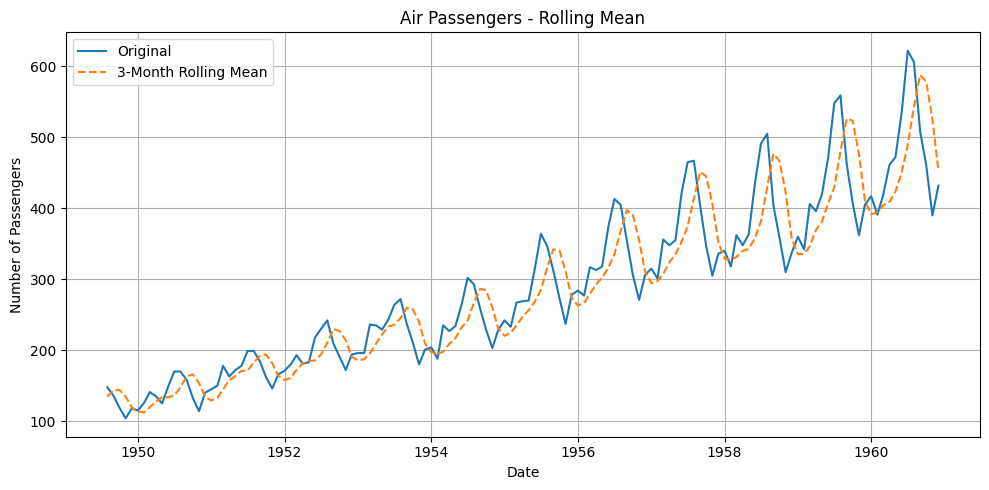

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Passengers'], label='Original')
plt.plot(df.index, df[f'Rolling_mean_{window}_Passengers'], label=f'{window}-Month Rolling Mean', linestyle='--')
plt.title('Air Passengers - Rolling Mean')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## ¿Is the Data Stationarity?

In [ ]:
def test_stationarity(df, window = 7):
    rol_mean = df[f'Rolling_mean_{window}_Passengers']
    rol_std = df[f'Rolling_std_{window}_Passengers']
    
    orig = plt.plot(df["Passengers"], color='blue', label='Original')
    mean = plt.plot(rol_mean, color='red', label='Rolling Mean')
    std = plt.plot(rol_std, color='black', label='Rolling std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)
    
    print('Results of Dickey-Fuller Test:')
    df_test = adfuller(df["Passengers"], autolag='AIC')
    df_output = pd.Series(df_test[0:4],index=['Test Statistic','p-value','#Lags Used',
                                           'Number of Observations Used'])
    for key,value in df_test[4].items():
        df_output['Critical Value (%s)'%key] = value
    print(df_output)

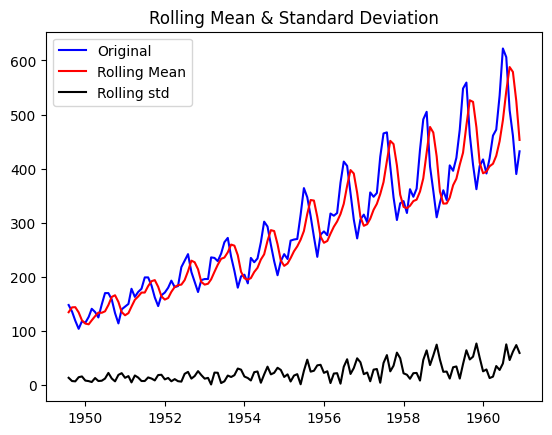

Results of Dickey-Fuller Test:
Test Statistic                   0.706807
p-value                          0.989973
#Lags Used                      13.000000
Number of Observations Used    123.000000
Critical Value (1%)             -3.484667
Critical Value (5%)             -2.885340
Critical Value (10%)            -2.579463
dtype: float64


In [12]:
test_stationarity(df, window = window)

1. Rolling Mean and Standard Deviation:

    - The rolling mean (red line) shows a clear upward trend, indicating that the average number of passengers is increasing over time.

    - The rolling standard deviation (black line) is not constant, it also increases slightly with time, suggesting variance is not stable.

    - Both observations indicate non-stationarity.

2. Dickey-Fuller Test Results:

    - Test Statistic = 0.706807, which is much higher than any of the critical values (-3.48, -2.88, -2.57).

    - p-value = 0.989973, which is far above 0.05.

    - Since the test statistic > critical values and p-value >> 0.05, we fail to reject the null hypothesis of the Dickey-Fuller test.

Conclusion:

- The time series is **non-stationary**.

- It has both a trend (upward) and seasonality (periodic fluctuations).

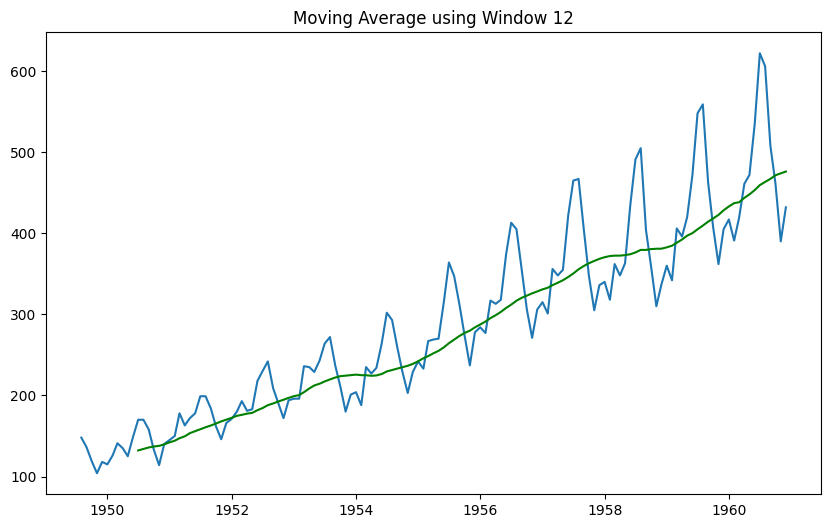

In [17]:
new_win = 12
moving_Average = df["Passengers"].rolling(window = new_win).mean()

plt.figure(figsize = (10, 6))
plt.plot(df["Passengers"])
plt.plot(moving_Average, color='green')
plt.title(f"Moving Average using Window {new_win}")
plt.show()